In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
# ── 1. Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('Country-data.csv')

print("=" * 60)
print("  COUNTRY DATASET - UNSUPERVISED LEARNING PIPELINE")
print("=" * 60)
print(f"\nShape        : {df.shape}")
print(f"Columns      : {list(df.columns)}")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
print(df.head())

  COUNTRY DATASET - UNSUPERVISED LEARNING PIPELINE

Shape        : (167, 10)
Columns      : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Missing vals : 0

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


  EXPLORATORY DATA ANALYSIS

── Missing Values per Column ──
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


NameError: name 'X' is not defined

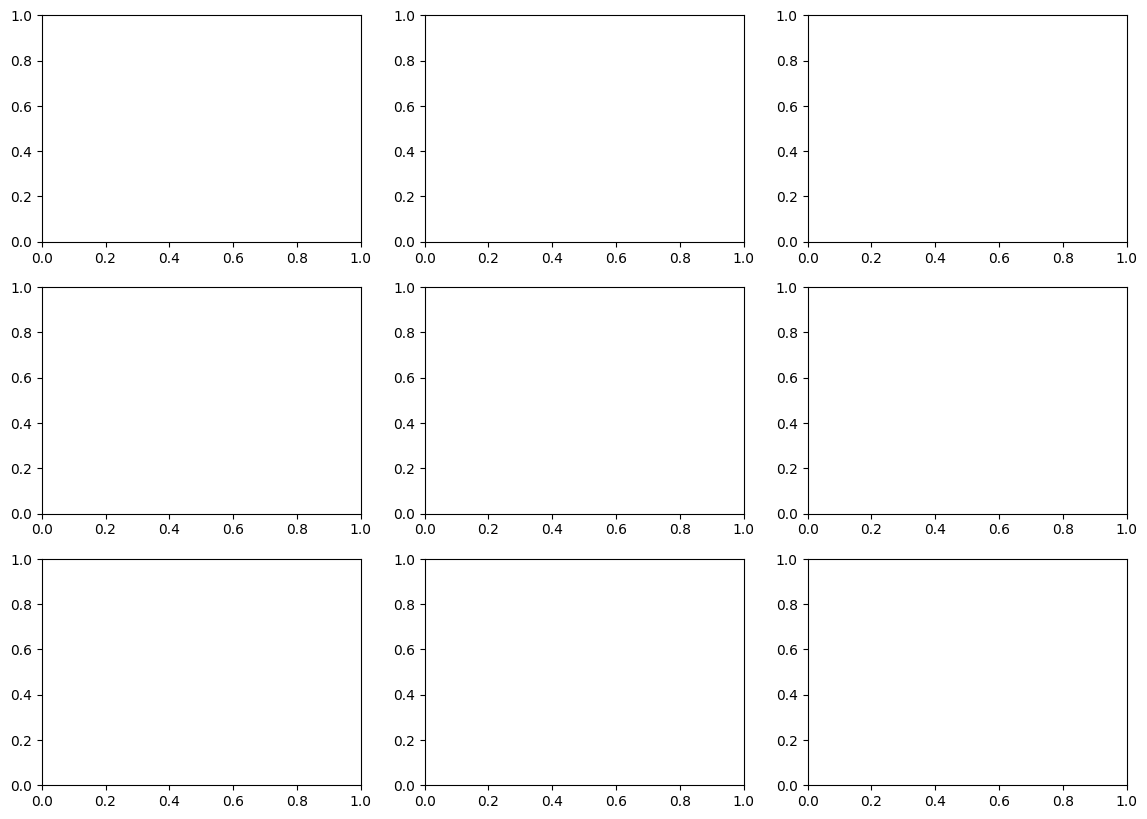

In [5]:
# ── EDA ───────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Missing values per column
print("\n── Missing Values per Column ──")
print(df.isnull().sum())

# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
colors = ['#6c5ce7', '#00b894', '#e17055', '#fdcb6e',
          '#0984e3', '#d63031', '#a29bfe', '#fd79a8', '#55efc4']

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png')
plt.show()
print("Saved eda_distributions.png")

# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='PuBu',
            linewidths=0.5, square=True, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()
print("Saved eda_correlation.png")

# Boxplots to check outliers
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].boxplot(X[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Outlier Detection (Boxplots)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png')
plt.show()
print("Saved eda_boxplots.png")

In [3]:
# ── 2. Separate country names & features ─────────────────────────────────────
country_names = df['country']
X = df.drop(columns=['country'])

print(f"\nFeatures used: {list(X.columns)}")
print(f"Feature shape: {X.shape}")

# ── 3. Scale the features ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete.")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(5)}")
print(f"Std  after scaling (should be ~1): {X_scaled.std(axis=0).round(5)}")


Features used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Feature shape: (167, 9)
Scaling complete.
Mean after scaling (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


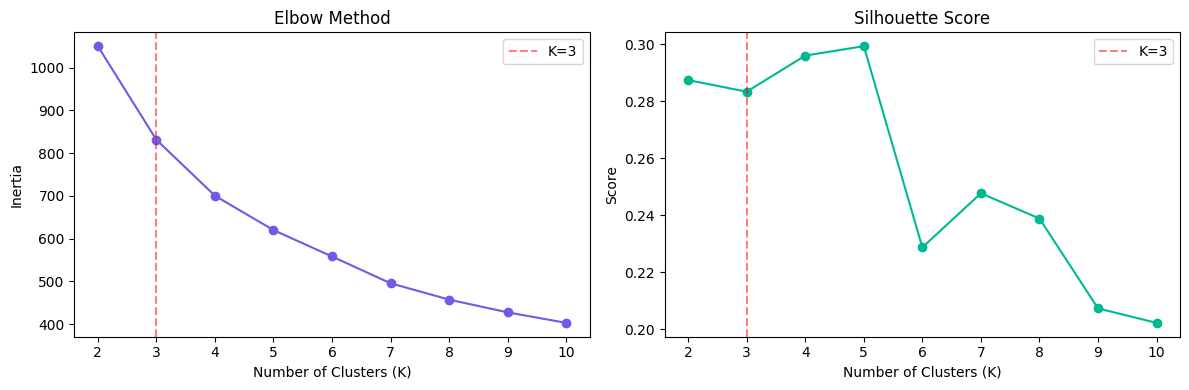

Plot saved as elbow_silhouette.png


In [4]:
# ── 4. Find optimal K using Elbow Method ─────────────────────────────────────
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, 'o-', color='#6c5ce7')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='K=3')
axes[0].legend()

axes[1].plot(K_range, silhouette, 'o-', color='#00b894')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='K=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png')
plt.show()
print("Plot saved as elbow_silhouette.png")

In [5]:
# ── 5. Train final KMeans with K=3 ───────────────────────────────────────────
K_BEST = 3

kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

print(f"KMeans trained with K={K_BEST}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

KMeans trained with K=3

Cluster distribution:
cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [6]:
# ── 6. Interpret clusters ─────────────────────────────────────────────────────
cluster_summary = df.groupby('cluster')[list(X.columns)].mean().round(2)
print("\nCluster mean values:")
print(cluster_summary)

# Label clusters based on GDP and child mortality
# (adjust labels after reviewing your output)
CLUSTER_LABELS = {
    0: "Developed",
    1: "Underdeveloped",
    2: "Developing"
}

print("\nCluster labels (review and adjust if needed):")
for k, label in CLUSTER_LABELS.items():
    countries = df[df['cluster'] == k]['country'].tolist()
    print(f"\n  Cluster {k} → {label} ({len(countries)} countries)")
    print(f"  Sample: {countries[:5]}")


Cluster mean values:
         child_mort  exports  health  imports    income  inflation  \
cluster                                                              
0              5.00    58.74    8.81    51.49  45672.22       2.67   
1             92.96    29.15    6.39    42.32   3942.40      12.02   
2             21.93    40.24    6.20    47.47  12305.60       7.60   

         life_expec  total_fer      gdpp  
cluster                                   
0             80.13       1.75  42494.44  
1             59.19       5.01   1922.38  
2             72.81       2.31   6486.45  

Cluster labels (review and adjust if needed):

  Cluster 0 → Developed (36 countries)
  Sample: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei']

  Cluster 1 → Underdeveloped (47 countries)
  Sample: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']

  Cluster 2 → Developing (84 countries)
  Sample: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']


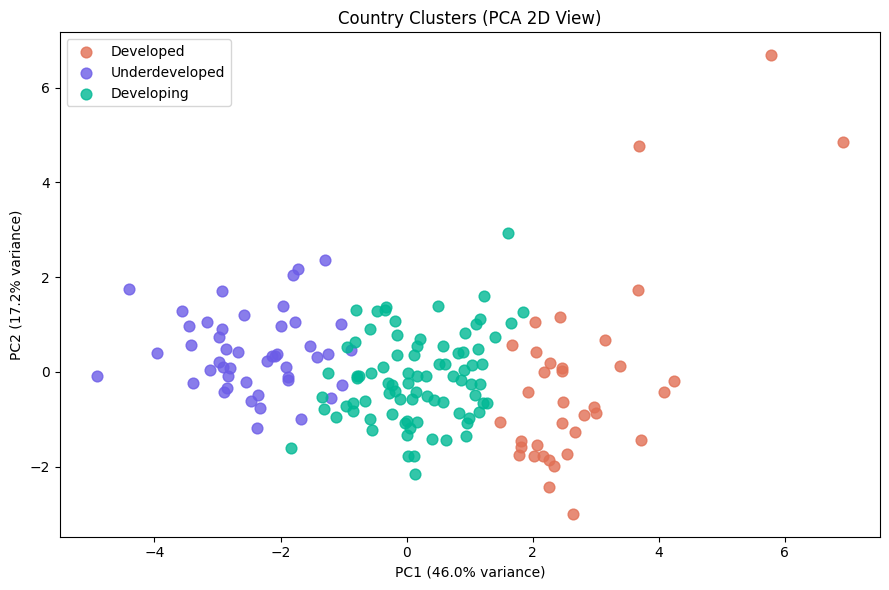

Plot saved as clusters_pca.png


In [7]:
# ── 7. PCA Visualisation ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['#e17055', '#6c5ce7', '#00b894']
for cluster_id in range(K_BEST):
    mask = kmeans.labels_ == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        label=CLUSTER_LABELS[cluster_id],
        s=60, alpha=0.8
    )

plt.title('Country Clusters (PCA 2D View)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig('clusters_pca.png')
plt.show()
print("Plot saved as clusters_pca.png")

In [ ]:
# ── Model Testing & Validation ────────────────────────────────────────────────
print("=" * 60)
print("  MODEL TESTING & VALIDATION")
print("=" * 60)

# Overall silhouette score
overall_sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"\nOverall Silhouette Score : {overall_sil:.4f}")
print("  (closer to 1.0 = well separated clusters)")

# Per-cluster silhouette
from sklearn.metrics import silhouette_samples
sample_sil = silhouette_samples(X_scaled, kmeans.labels_)
print("\n── Per-Cluster Silhouette ──")
for k in range(K_BEST):
    mask = kmeans.labels_ == k
    mean_sil = sample_sil[mask].mean()
    print(f"  Cluster {k} ({CLUSTER_LABELS[k]:15s}) : {mean_sil:.4f}  ({mask.sum()} countries)")

# Inertia summary
print(f"\n── Inertia Summary ──")
print(f"  Final inertia (K=3) : {kmeans.inertia_:.2f}")
print(f"  (lower = tighter clusters)")

# Cluster size balance
print(f"\n── Cluster Size Balance ──")
for k in range(K_BEST):
    count = (kmeans.labels_ == k).sum()
    pct = count / len(df) * 100
    print(f"  Cluster {k} ({CLUSTER_LABELS[k]:15s}) : {count} countries ({pct:.1f}%)")

# Sample predictions — test with known countries
print(f"\n── Sample Predictions (Known Countries) ──")
test_countries = {
    'USA'         : [6.0,  13.58, 17.9, 16.58, 53000, 1.49, 78.9, 1.82, 53470],
    'Afghanistan' : [90.2, 10.0,  7.58, 44.9,  1610,  9.44, 56.2, 5.82, 553  ],
    'Thailand'    : [12.9, 69.0,  4.08, 60.7,  14950, 3.03, 74.7, 1.53, 5870 ],
}

for country, values in test_countries.items():
    sample = np.array([values])
    sample_scaled = scaler.transform(sample)
    cluster_id = int(kmeans.predict(sample_scaled)[0])
    label = CLUSTER_LABELS[cluster_id]
    print(f"  {country:15s} → Cluster {cluster_id} ({label})")

print("\n  ALL MODEL TESTS COMPLETE")

In [10]:
# ── 8. Save pipeline ──────────────────────────────────────────────────────────
pipeline = {
    'scaler': scaler,
    'kmeans': kmeans,
    'cluster_labels': CLUSTER_LABELS,
    'feature_names': list(X.columns)
}

with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("Saved model.pkl")
print(f"  Scaler   : StandardScaler (fitted on {X.shape[0]} countries)")
print(f"  KMeans   : K={K_BEST}, random_state=42")
print(f"  Labels   : {CLUSTER_LABELS}")
print(f"  Features : {list(X.columns)}")

Saved model.pkl
  Scaler   : StandardScaler (fitted on 167 countries)
  KMeans   : K=3, random_state=42
  Labels   : {0: 'Developing', 1: 'Underdeveloped', 2: 'Developed'}
  Features : ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
